In [1]:
import os
import sys
from sklearn.dummy import DummyClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

sys.path.append(os.path.abspath('..'))

from src.model_utils import (
    load_encoded_splits,
    evaluate_classifier,
    plot_metric_scorecards,
    get_confusion_matrix_df,
    plot_roc_curve,
    run_random_search
)

In [2]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR, version="enhanced")

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 86), y_train: (60876,)
X_val:   (13045, 86), y_val:   (13045,)
X_test:  (13046, 86), y_test:  (13046,)


In [3]:
SEED = 42

pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

param_distributions = {
        'classifier__C': np.logspace(-3, 2, 20)
    }

In [4]:
search = run_random_search(
    estimator=pipeline,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    n_iter=8,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

best_rf = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV f1: {search.best_score_:.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'classifier__C': np.float64(0.7847599703514607)}
Best CV f1: 0.5776


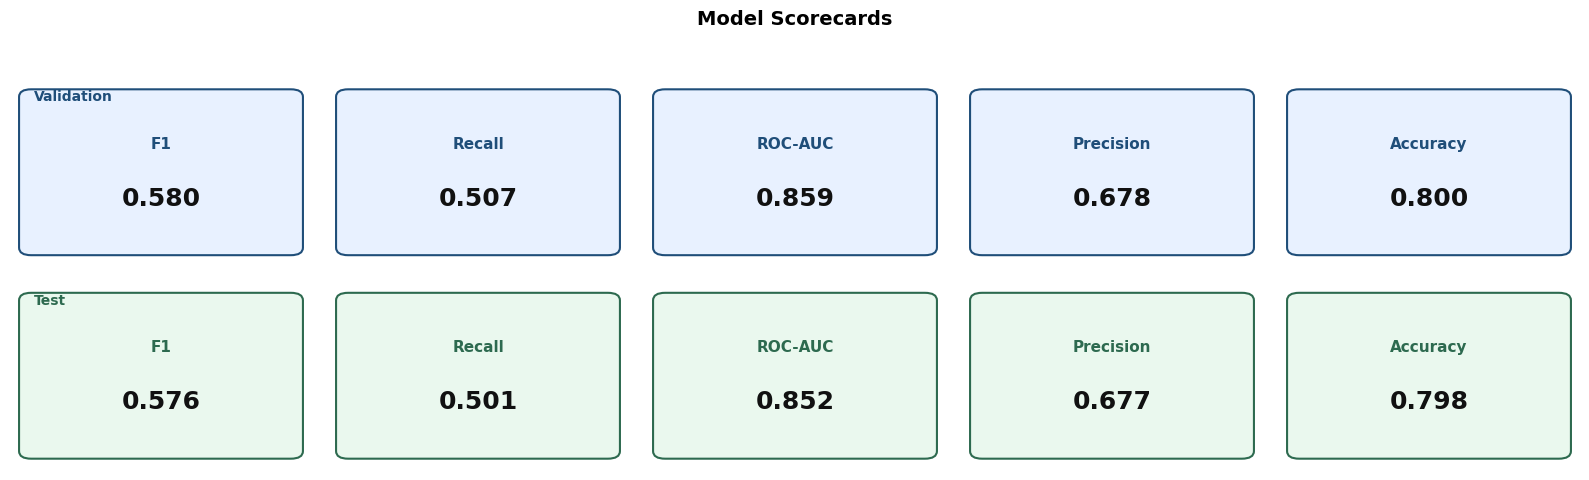

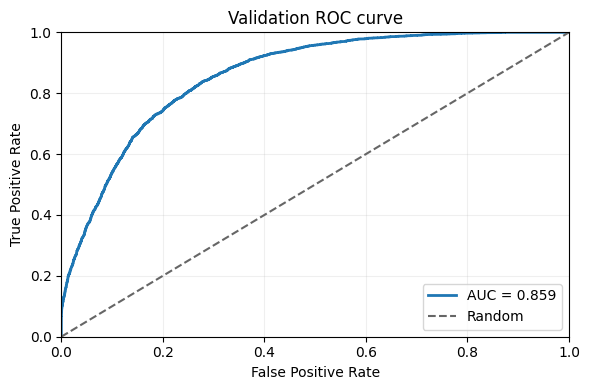

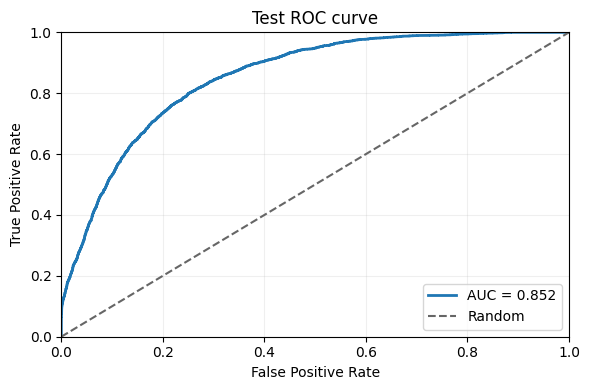

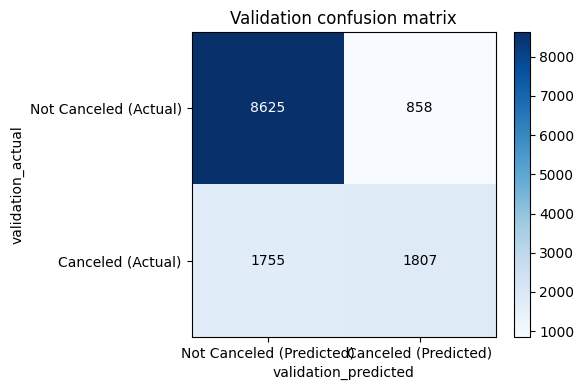

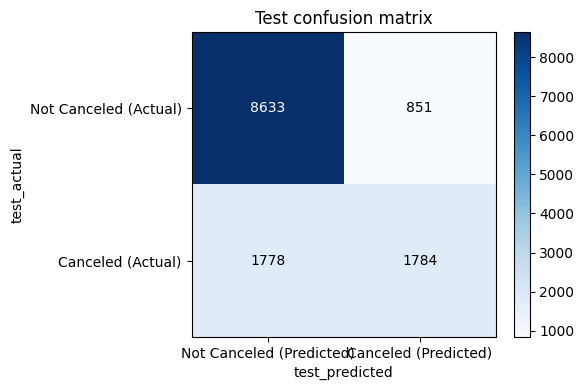

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.7997,0.678,0.5073,0.5804,0.8591
1,test,0.7985,0.677,0.5008,0.5758,0.8523


In [5]:
val_results = evaluate_classifier(best_rf, X_val, y_val, 'validation')
test_results = evaluate_classifier(best_rf, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results)
plot_roc_curve(best_rf, X_val, y_val, 'validation')
plot_roc_curve(best_rf, X_test, y_test, 'test')
val_cm = get_confusion_matrix_df(best_rf, X_val, y_val, 'validation', plot=True)
test_cm = get_confusion_matrix_df(best_rf, X_test, y_test, 'test', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))

In [6]:
classifier = best_rf.named_steps['classifier'] # type: ignore

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.abs(classifier.coef_[0]),
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

,feature,importance
14,required_car_parking_spaces,2.174471
47,cancellation_ratio,0.653437
15,total_of_special_requests,0.649579
31,country_PRT,0.585723
0,lead_time,0.500371
19,agent_9,0.440588
20,agent_240,0.354545
29,agent_other,0.340050
8,is_repeated_guest,0.320117
44,week_cos,0.293587
